# Market Data Loader — Yahoo Finance & Binance

In [2]:
# !pip install yfinance pandas requests "websockets>=17" 
# !pip install --upgrade mplfinance


## Data source interface

Common shape both feeds implement: `history()` returns an OHLCV `DataFrame`, `stream()` blocks pushing normalized tick dicts until told to stop.

In [3]:
from __future__ import annotations

import json
import threading
from abc import ABC, abstractmethod
from concurrent.futures import ThreadPoolExecutor
from dataclasses import dataclass
from typing import Callable

import pandas as pd
import requests
import yfinance as yf
from websockets.sync.client import connect as ws_connect


@dataclass
class DataRequest:
    """One symbol to load/stream. `timeframe` uses Binance-style tokens
    (1m, 5m, 15m, 1h, 4h, 1d, ...); YahooFeed maps/resamples as needed."""
    source: str       # "yahoo" | "binance"
    symbol: str        # "AAPL" | "BTCUSDT"
    timeframe: str = "1h"


def _parse_date(date_str: str) -> pd.Timestamp:
    """Parse "YYYYMMDD" -> UTC Timestamp."""
    return pd.Timestamp(date_str, tz="UTC")


class DataFeed(ABC):
    """Common interface every market data source implements."""

    @abstractmethod
    def history(self, symbol: str, timeframe: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
        """Return OHLCV DataFrame indexed by UTC datetime."""

    @abstractmethod
    def stream(self, symbols: list[str], timeframe: str, on_tick: Callable[[dict], None], stop: threading.Event) -> None:
        """Block, pushing normalized tick/kline dicts to `on_tick` until `stop` is set."""


## Yahoo Finance feed

History via `yfinance`; realtime via its built-in `yf.WebSocket`. yfinance has no native 4h/3d bar, so those are fetched at the closest supported bar and resampled.

In [4]:
class YahooFeed(DataFeed):
    _RESAMPLE_FALLBACK = {"4h": ("1h", "4h"), "3d": ("1d", "3D"), "1w": ("1d", "1W")}

    def history(self, symbol: str, timeframe: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
        fetch_tf, resample_rule = self._RESAMPLE_FALLBACK.get(timeframe, (timeframe, None))
        df = yf.Ticker(symbol).history(start=start, end=end, interval=fetch_tf, auto_adjust=False)
        df = df.rename(columns=str.lower)[["open", "high", "low", "close", "volume"]]
        df.index = pd.to_datetime(df.index, utc=True)
        if resample_rule:
            df = df.resample(resample_rule).agg(
                {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
            ).dropna()
        return df

    def stream(self, symbols, timeframe, on_tick, stop):
        ws = yf.WebSocket(verbose=False)
        ws.subscribe(symbols)

        def handler(msg: dict):
            on_tick({"source": "yahoo", **msg})
            if stop.is_set():
                raise KeyboardInterrupt  # yfinance's listen() loop exits on this

        try:
            ws.listen(handler)
        finally:
            ws.close()


## Binance feed

History via the public REST klines endpoint (paginated 1000 candles/request, no key needed); realtime via Binance's combined kline WebSocket stream.

In [5]:
class BinanceFeed(DataFeed):
    _REST = "https://api.binance.com/api/v3/klines"
    _WS = "wss://stream.binance.com:9443/stream"
    _COLS = ["open_time", "open", "high", "low", "close", "volume", "close_time",
             "quote_volume", "trades", "taker_base_vol", "taker_quote_vol", "ignore"]

    def history(self, symbol: str, timeframe: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
        start_ms, end_ms = int(start.timestamp() * 1000), int(end.timestamp() * 1000)
        frames = []
        while start_ms < end_ms:
            resp = requests.get(self._REST, params={
                "symbol": symbol, "interval": timeframe,
                "startTime": start_ms, "endTime": end_ms, "limit": 1000,
            }, timeout=30)
            resp.raise_for_status()
            batch = resp.json()
            if not batch:
                break
            frames.append(pd.DataFrame(batch, columns=self._COLS))
            start_ms = batch[-1][6] + 1  # next candle after last close_time

        if not frames:
            return pd.DataFrame(columns=["open", "high", "low", "close", "volume"])

        df = pd.concat(frames, ignore_index=True)
        df.index = pd.to_datetime(df["open_time"], unit="ms", utc=True)
        return df[["open", "high", "low", "close", "volume"]].astype(float)

    def stream(self, symbols, timeframe, on_tick, stop):
        streams = "/".join(f"{s.lower()}@kline_{timeframe}" for s in symbols)
        with ws_connect(f"{self._WS}?streams={streams}") as ws:
            while not stop.is_set():
                try:
                    msg = json.loads(ws.recv(timeout=1))
                except TimeoutError:
                    continue
                on_tick({"source": "binance", **msg["data"]})


## Facade

`MarketDataLoader.load_history` fetches every requested symbol concurrently (any mix of sources/timeframes) into one wide `DataFrame` with `MultiIndex` columns `(symbol, field)`. `stream` runs one background thread per source and normalizes ticks into a single callback.

In [6]:
class MarketDataLoader:
    """Load history / stream ticks from Yahoo Finance and Binance behind one API."""

    _FEEDS: dict[str, DataFeed] = {"yahoo": YahooFeed(), "binance": BinanceFeed()}

    def load_history(self, requests_: list[DataRequest], start: str, end: str) -> pd.DataFrame:
        """
        start, end: "YYYYMMDD"
        Returns one DataFrame, columns = MultiIndex (symbol, field).
        """
        start_ts, end_ts = _parse_date(start), _parse_date(end)

        with ThreadPoolExecutor(max_workers=len(requests_) or 1) as pool:
            results = list(pool.map(
                lambda r: self._FEEDS[r.source].history(r.symbol, r.timeframe, start_ts, end_ts),
                requests_,
            ))

        return pd.concat(results, axis=1, keys=[r.symbol for r in requests_])

    def stream(self, requests_: list[DataRequest], on_tick: Callable[[dict], None]) -> "StreamHandle":
        """Start one background thread per source; normalized ticks go to `on_tick`."""
        stop = threading.Event()
        by_source: dict[str, list[DataRequest]] = {}
        for r in requests_:
            by_source.setdefault(r.source, []).append(r)

        threads = []
        for source, reqs in by_source.items():
            feed = self._FEEDS[source]
            symbols = [r.symbol for r in reqs]
            timeframe = reqs[0].timeframe  # one timeframe per source per stream call
            t = threading.Thread(target=feed.stream, args=(symbols, timeframe, on_tick, stop), daemon=True)
            t.start()
            threads.append(t)

        return StreamHandle(stop, threads)


@dataclass
class StreamHandle:
    _stop: threading.Event
    _threads: list[threading.Thread]

    def stop(self, timeout: float = 5.0) -> None:
        self._stop.set()
        for t in self._threads:
            t.join(timeout=timeout)


## Example — history, multi-source in one call

In [7]:
loader = MarketDataLoader()

requests_ = [
    DataRequest(source="yahoo", symbol="AAPL", timeframe="4h"),
    DataRequest(source="binance", symbol="BTCUSDT", timeframe="1h"),
]

data = loader.load_history(requests_, start="20260801", end="20260815")
data["AAPL"].tail()


C:\Users\poowa\AppData\Local\Temp\ipykernel_24244\1716776242.py:19: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(results, axis=1, keys=[r.symbol for r in requests_])


,open,high,low,close,volume
2026-08-14 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2026-08-14 21:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2026-08-14 22:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2026-08-14 23:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2026-08-15 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN


## Example — realtime stream

In [8]:
ticks = []

handle = loader.stream(
    [DataRequest("yahoo", "AAPL", "1m"), DataRequest("binance", "BTCUSDT", "1m")],
    on_tick=lambda t: ticks.append(t),
)

# ... let it run, then:
# handle.stop()


# Volume

In [101]:
loader = MarketDataLoader()

requests_ = [
    DataRequest(source="binance", symbol="BTCUSDT", timeframe="1h"),
]

data = loader.load_history(requests_, start="20260101", end="20260820")
data["BTCUSDT"].head()

,open,high,low,close,volume
open_time,,,,,
2026-01-01 00:00:00+00:00,87648.21,87849.26,87632.74,87809.23,233.66036
2026-01-01 01:00:00+00:00,87809.24,88050.00,87809.23,87960.00,241.44162
2026-01-01 02:00:00+00:00,87960.01,88088.10,87895.37,87914.00,209.55860
2026-01-01 03:00:00+00:00,87914.00,88015.70,87832.09,87846.02,149.08354
2026-01-01 04:00:00+00:00,87846.01,87854.81,87550.43,87590.40,476.17901


## Compare Volume Anomaly Detection

### Chart — price with volume-flag markers (mplfinance)

Plots the candlestick chart with a red marker above every bar where `volume_flag` is `True` (the anomalies).

In [71]:
# !pip install mplfinance
import mplfinance as mpf

def plot_volume_flags(df: pd.DataFrame, flag_col: str = "volume_flag", title: str = "Volume anomaly flags"):
    """df: OHLCV DataFrame (lowercase columns) with a boolean flag_col marking anomalies."""
    ohlc = df.rename(columns=str.capitalize)[["Open", "High", "Low", "Close", "Volume"]]

    # marker sits just above each flagged bar's high; NaN elsewhere so mplfinance skips those points
    marker_price = df["high"].where(df[flag_col].isin([True])) * 1.01

    apds = [mpf.make_addplot(marker_price, type="scatter", markersize=80, marker="v", color="red")]
    mpf.plot(ohlc, type="candle", volume=True, addplot=apds, style="yahoo", title=title)


#plot_volume_flags(temp_data, flag_col="volume_flag", title="Volume anomaly flags (first 10 rows)")


### Animated chart — bars grow in, flags appear live (mplfinance)

Follows mplfinance's [external-axes-mode animation pattern](https://github.com/matplotlib/mplfinance/blob/master/markdown/animation.md): build the figure once with `returnfig=True`, then each `FuncAnimation` frame clears the axes and redraws a growing slice of `df` via `mpf.plot(..., ax=..., volume=...)`. The `volume_flag` marker addplot is rebuilt every frame from the current slice, so a red ▼ appears exactly when the growing chart reaches that flagged bar.

`to_jshtml()` renders inline in the notebook without needing ffmpeg/imagemagick — but it embeds every frame as base64, so keep `n_frames` modest (a few dozen) for large series.

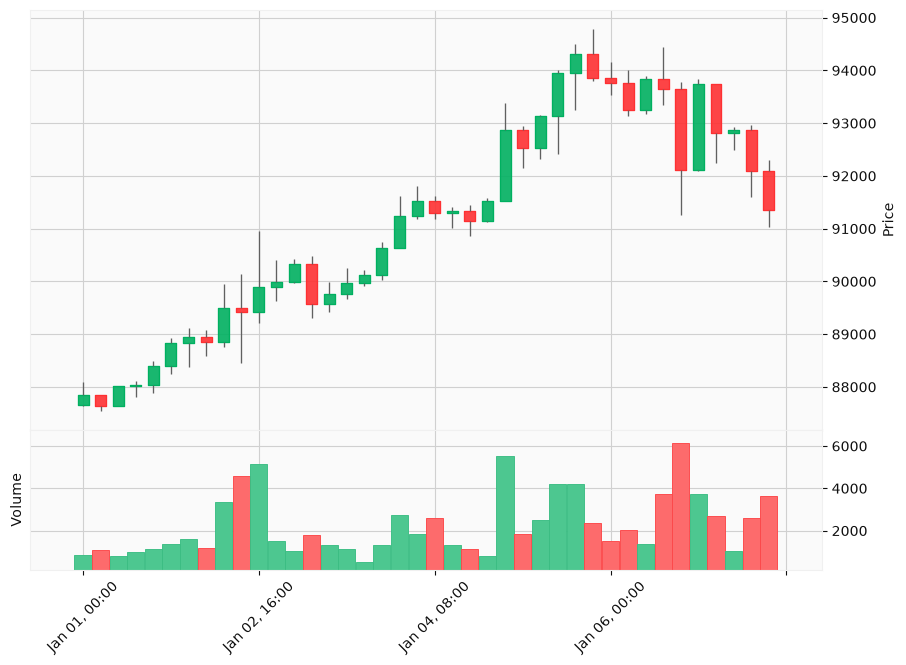

In [ ]:
# !pip install ipython  (already a notebook dependency, listed for completeness)
import matplotlib.animation as animation
from IPython.display import HTML


def animate_volume_flags(df: pd.DataFrame, flag_col: str = "volume_flag",
                          start: int = 40, step: int = 3, interval: int = 150,
                          n_frames: int = 40) -> animation.FuncAnimation:
    """Grow the candlestick chart bar-by-bar, revealing volume_flag markers as they occur.

    start: bars shown in the first frame (needs enough history for the rolling window to be non-NaN).
    step: bars added per frame. interval: ms between frames. n_frames: total frames to render.
    """
    window = df.iloc[:start]
    fig, axes = mpf.plot(window, type="candle", volume=True, style="yahoo",
                          returnfig=True, figsize=(11, 8), panel_ratios=(3, 1))
    ax_price, ax_volume = axes[0], axes[2]

    def animate(ival):
        end = start + ival * step
        if end > len(df):
            ani.event_source.stop()
            return
        data = df.iloc[:end]
        marker_price = data["high"].where(data[flag_col].fillna(False)) * 1.01
        apds = [mpf.make_addplot(marker_price, type="scatter", markersize=80,
                                  marker="v", color="red", ax=ax_price)]
        ax_price.clear()
        ax_volume.clear()
        mpf.plot(data, type="candle", ax=ax_price, volume=ax_volume, addplot=apds, style="yahoo")

    return animation.FuncAnimation(fig, animate, frames=n_frames, interval=interval, repeat=False)


# ani = animate_volume_flags(temp_data, flag_col="volume_flag", start=40, step=3, interval=150, n_frames=40)
# HTML(ani.to_jshtml())


### Robust baseline (median/MAD) instead of naive z-score

#### How to build it — steps
1. Take a rolling (or full-history) window of volume, excluding or downweighting the current bar! if possible (see leave-one-out in concept 2 for the strict version).
2. Compute `med = median(window).`
3. Compute `mad = median(abs(window - med))`. If `mad == 0` (flat/illiquid window), fall back to a small floor value or naive std to avoid division by zero.
4. Compute `z = 0.6745 * (current_volume - med) / mad`.
5. Flag anomaly if `abs(z) > threshold` (start with 3.5, a common robust-z convention).

In [102]:
import numpy as np
import pandas as pd

def robust_z(volume: pd.Series, window: int = 20) -> pd.Series:
    med = volume.rolling(window).median()
    mad = (volume - med).abs().rolling(window).median()
    mad = mad.replace(0, np.nan)  # avoid div-by-zero on flat windows
    return 0.6745 * (volume - med) / mad

def find_robust(volume: pd.Series, window: int = 20) -> pd.Series:
    return robust_z(volume, window)

In [105]:
temp_data = data["BTCUSDT"].copy()
temp_data["volume_z_score"] = find_robust(temp_data["volume"], window=48)
temp_data["volume_flag"] = temp_data["volume_z_score"].abs() > 2  # True = anomaly (was inverted)
temp_data = temp_data.dropna(subset=["volume_z_score"])  # drop initial NaNs from rolling window
temp_data.head(10)

,open,high,low,close,volume,volume_z_score,volume_flag
open_time,,,,,,,
2026-01-04 22:00:00+00:00,91279.99,91401.98,91150.47,91220.01,149.03275,-1.053324,False
2026-01-04 23:00:00+00:00,91220.00,91590.00,91220.00,91529.73,388.43188,0.575133,False
2026-01-05 00:00:00+00:00,91529.74,92426.82,91514.81,92405.46,2061.87264,11.948330,True
2026-01-05 01:00:00+00:00,92405.46,93388.00,92280.69,92967.28,1977.50385,11.231796,True
2026-01-05 02:00:00+00:00,92967.29,93157.99,92724.98,93033.11,913.68581,3.806593,True
2026-01-05 03:00:00+00:00,93033.11,93204.70,92871.26,92878.22,595.50021,1.724352,False
2026-01-05 04:00:00+00:00,92878.22,92947.87,92330.46,92595.07,588.83873,1.617058,False
2026-01-05 05:00:00+00:00,92595.07,92720.73,92340.39,92359.99,400.53800,0.319959,False
2026-01-05 06:00:00+00:00,92359.99,92500.00,92155.00,92491.81,320.70875,-0.173693,False


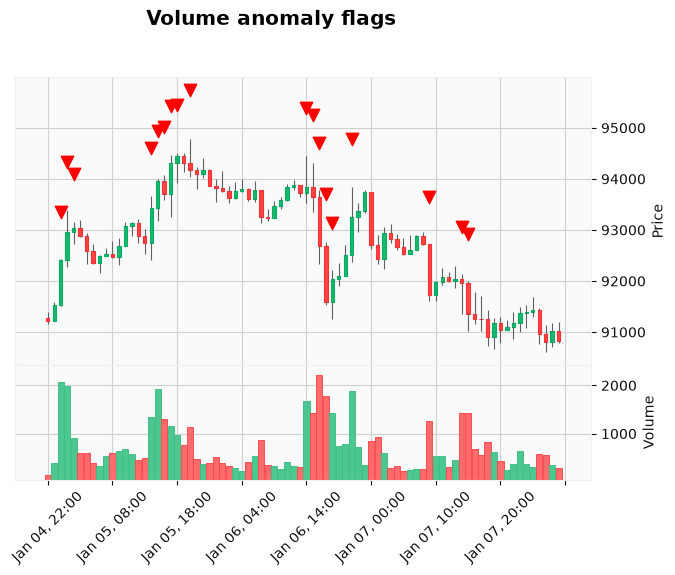

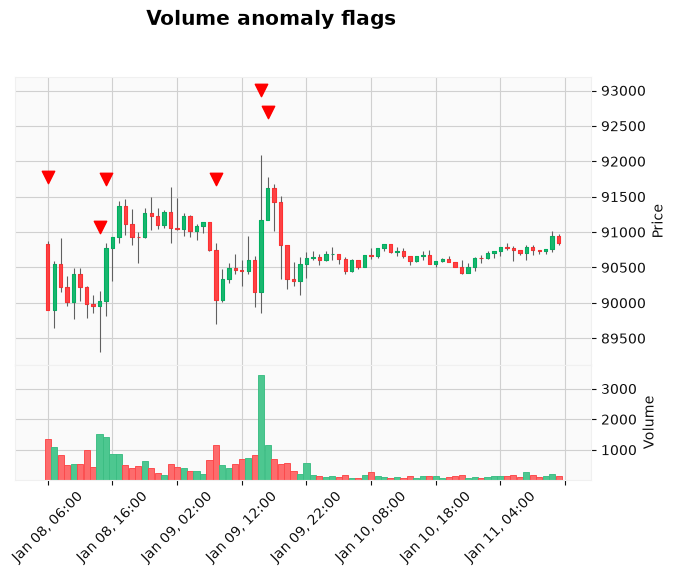

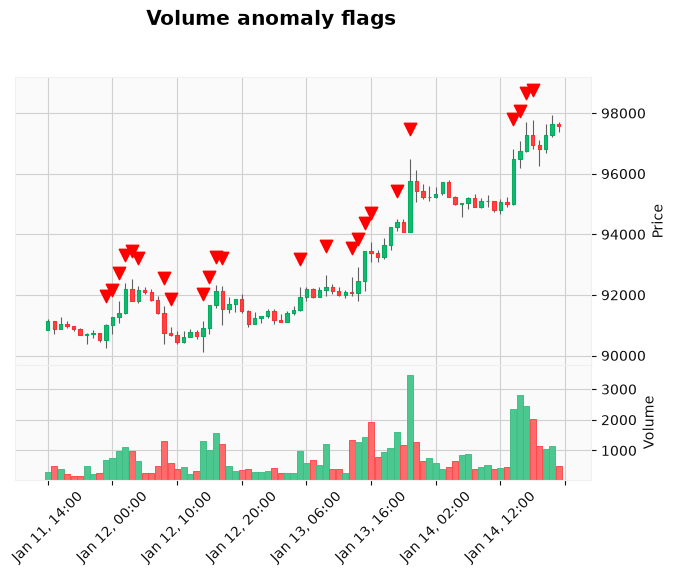

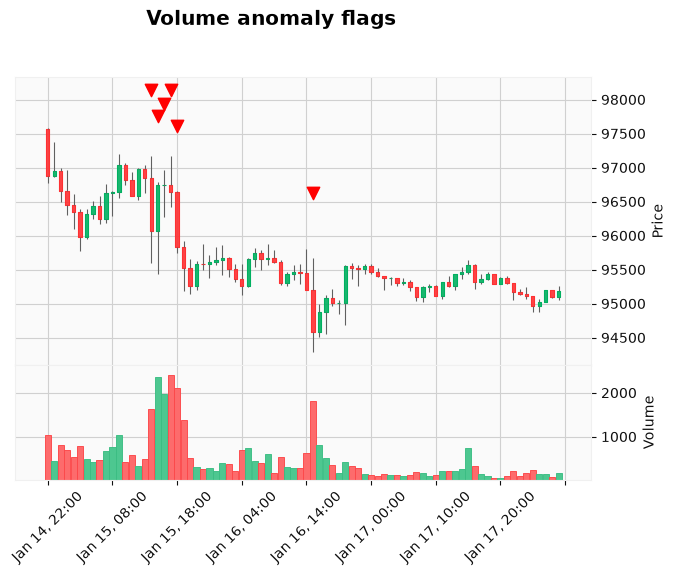

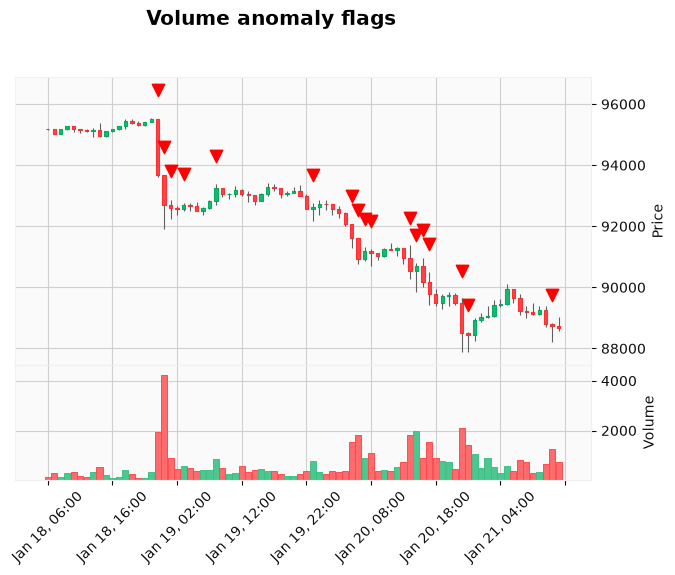

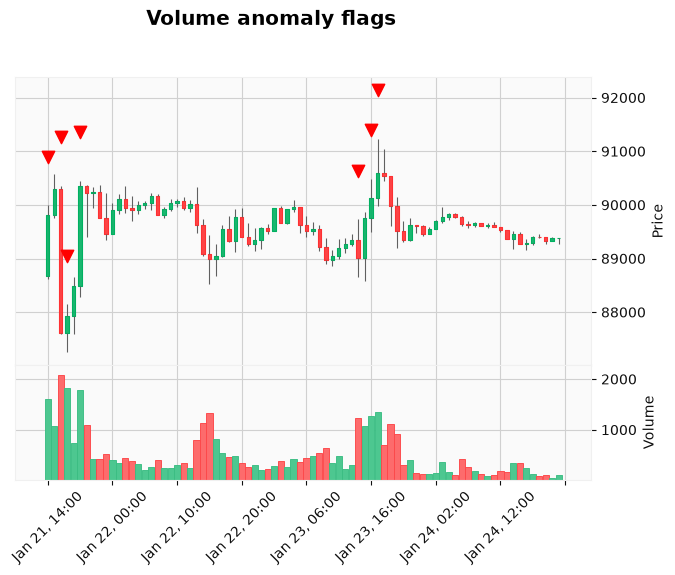

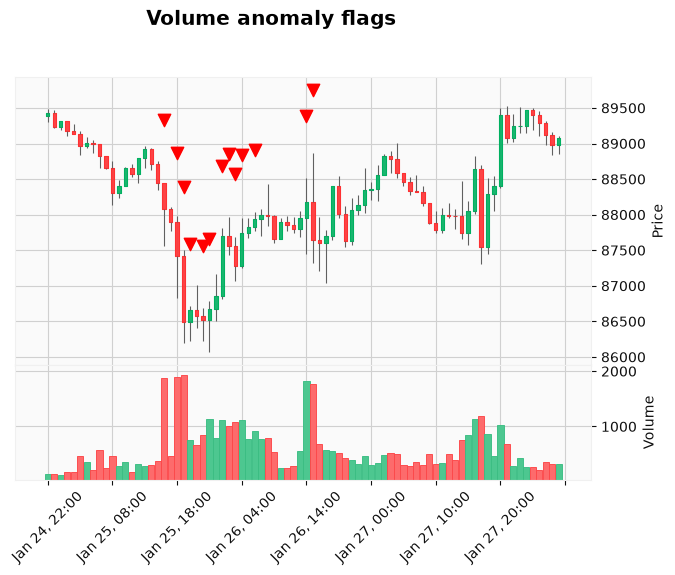

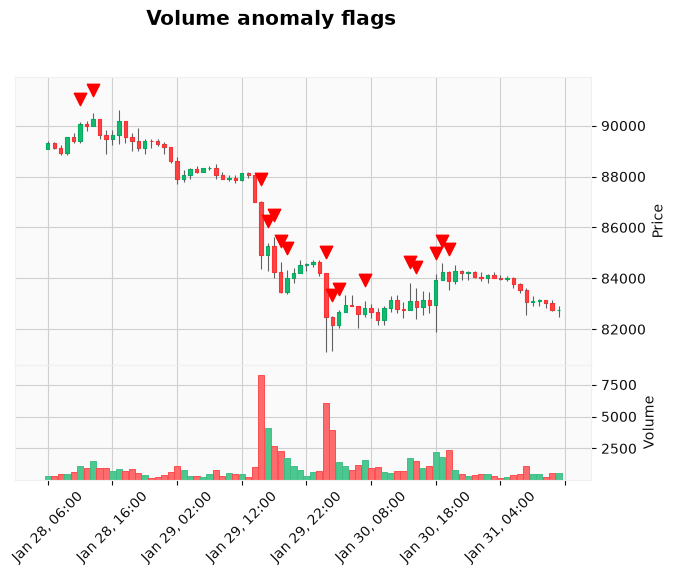

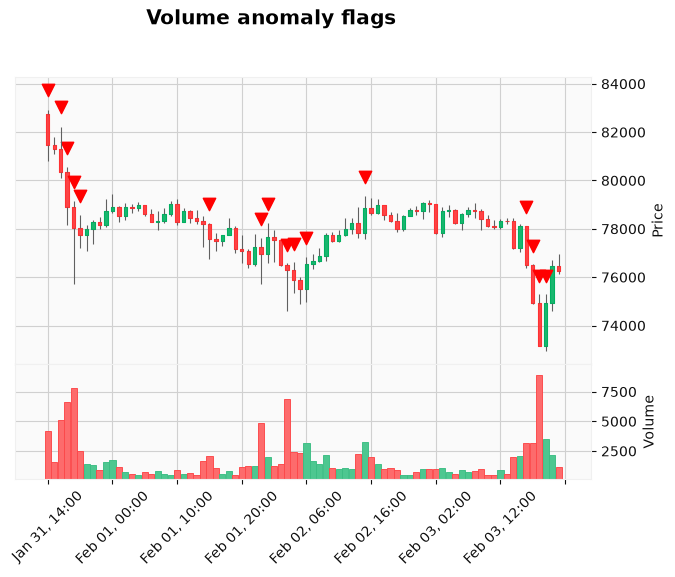

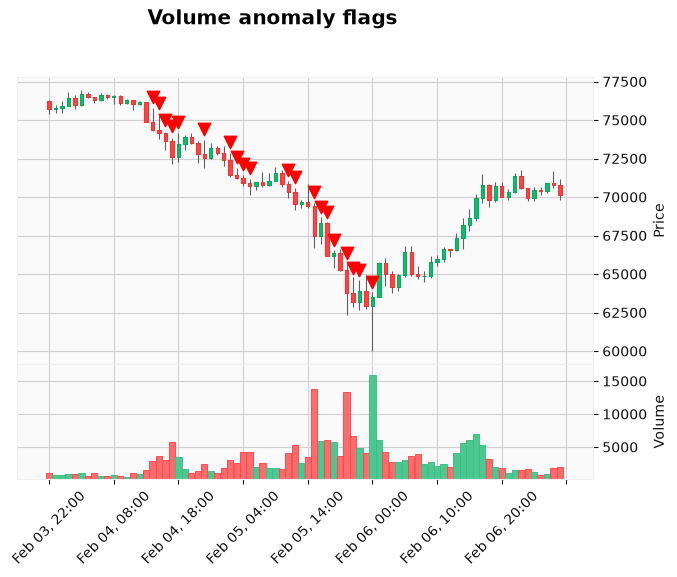

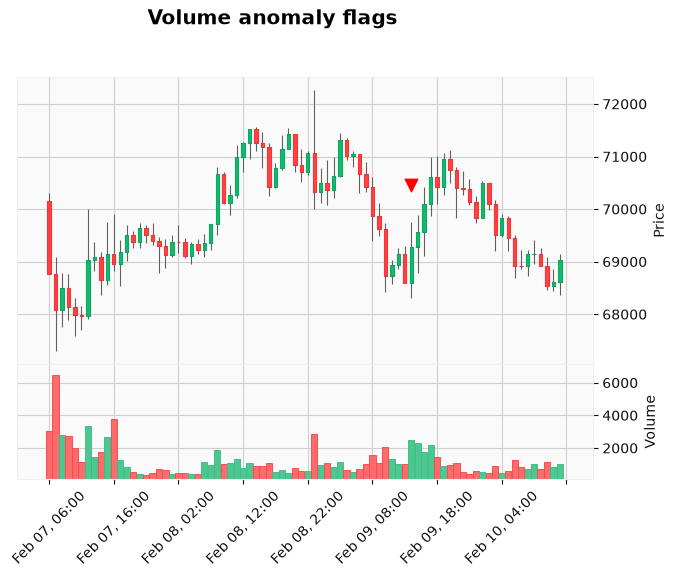

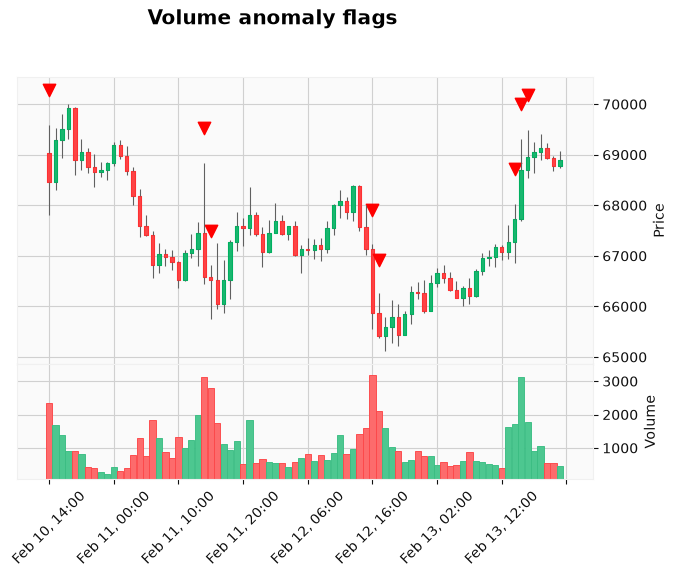

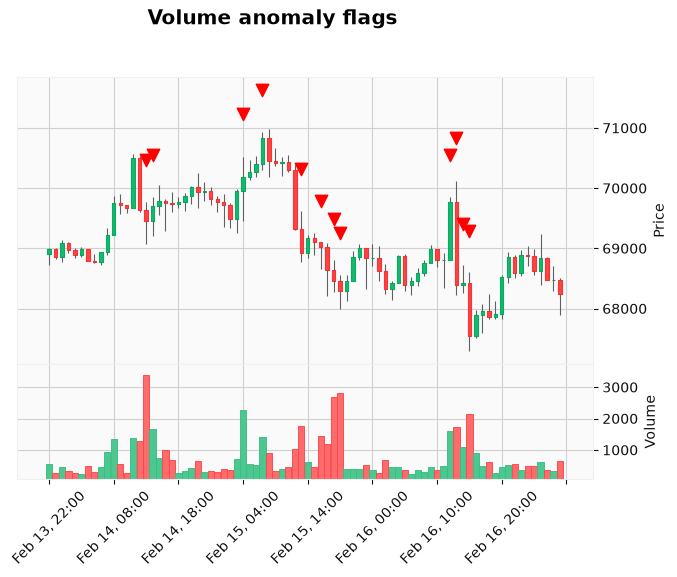

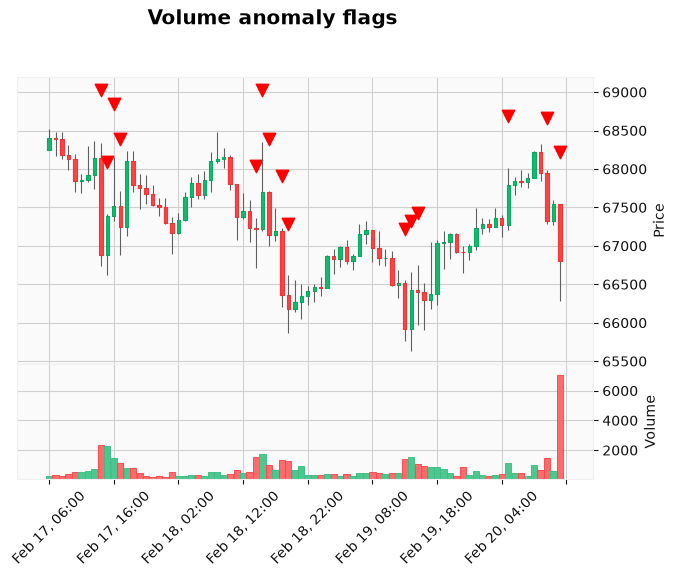

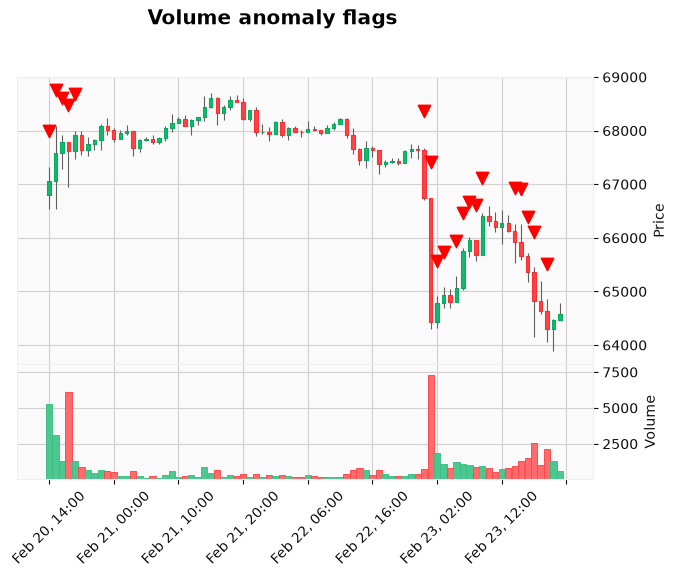

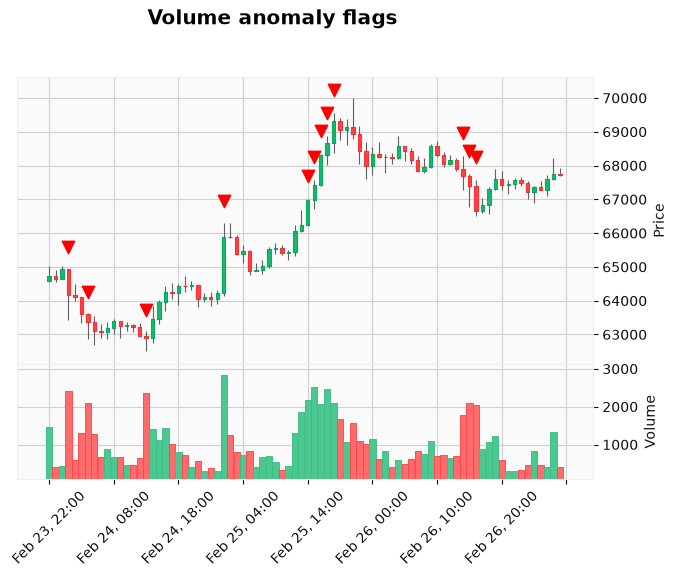

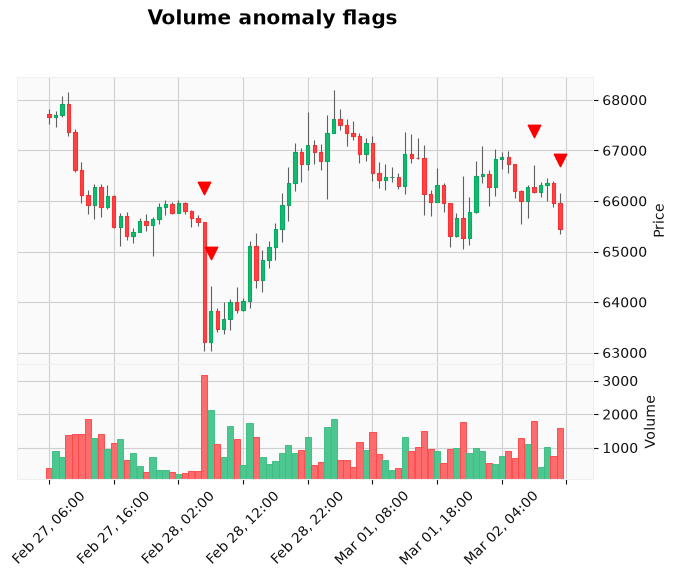

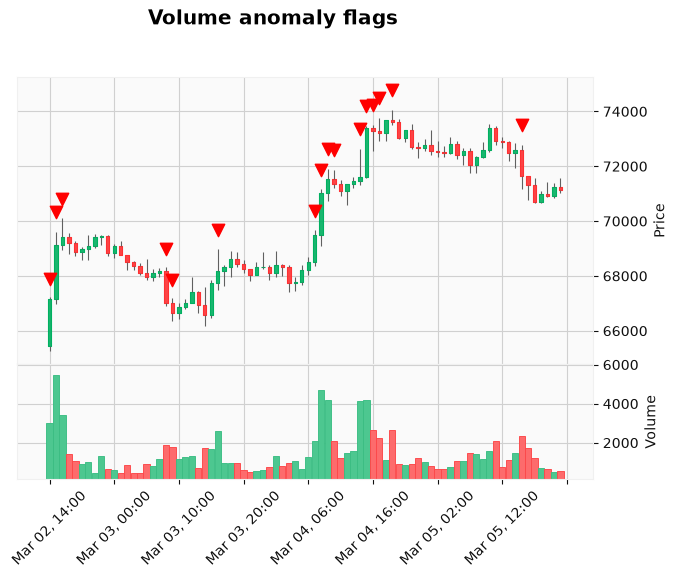

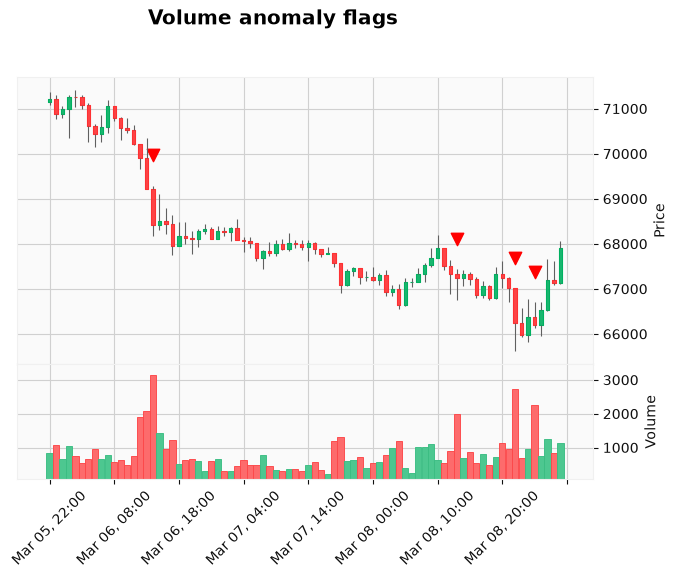

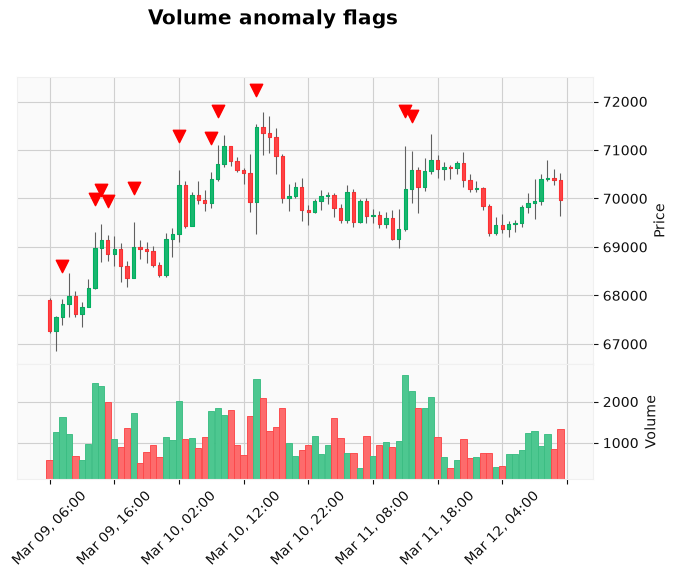

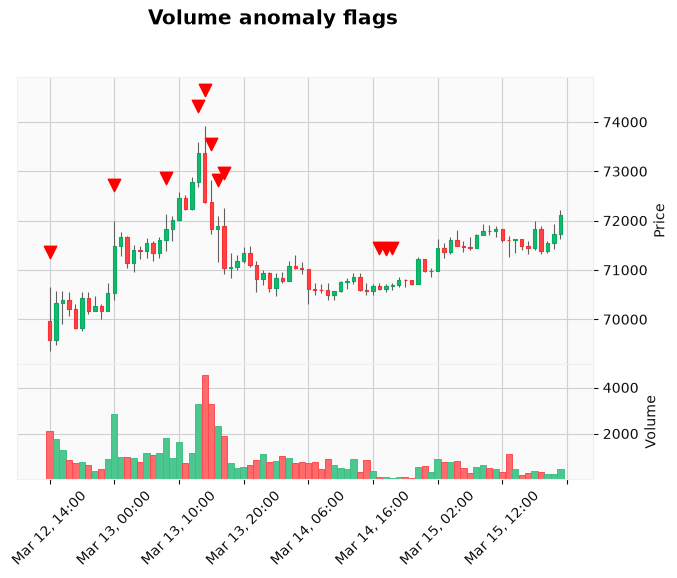

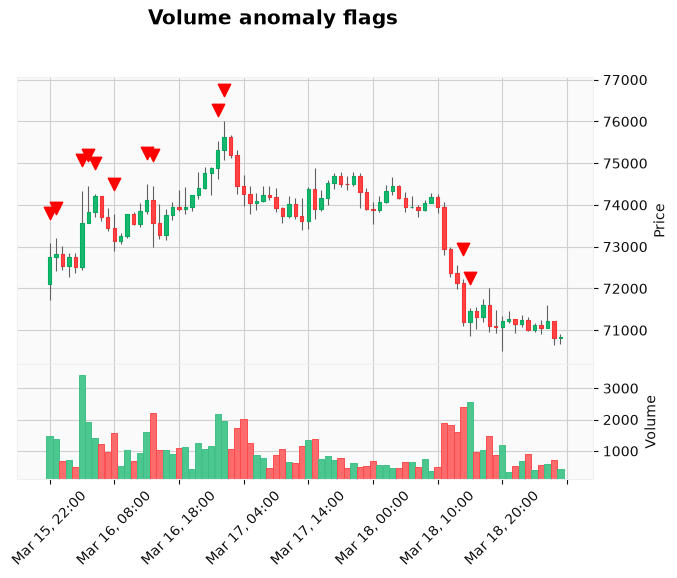

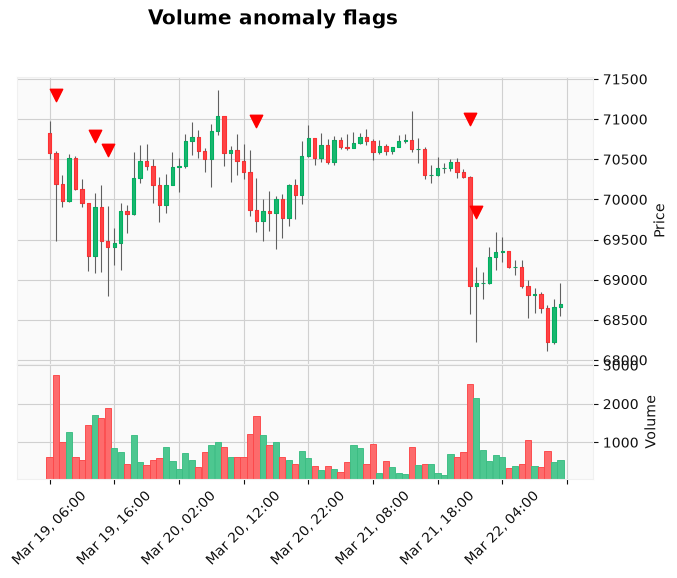

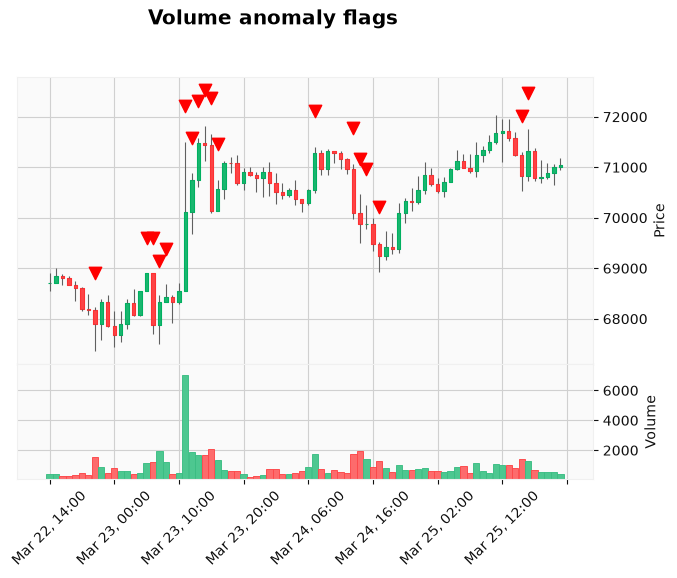

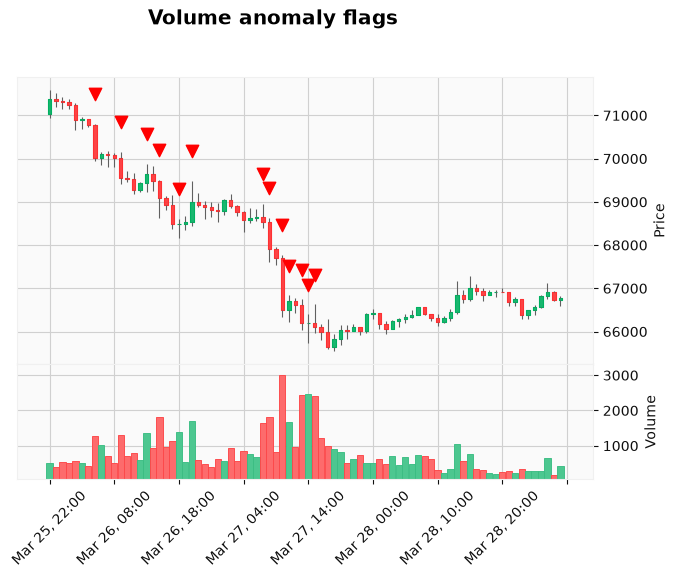

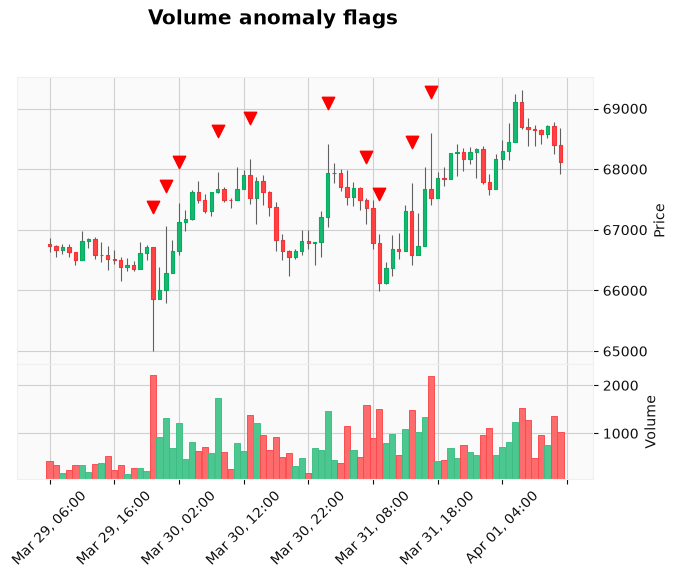

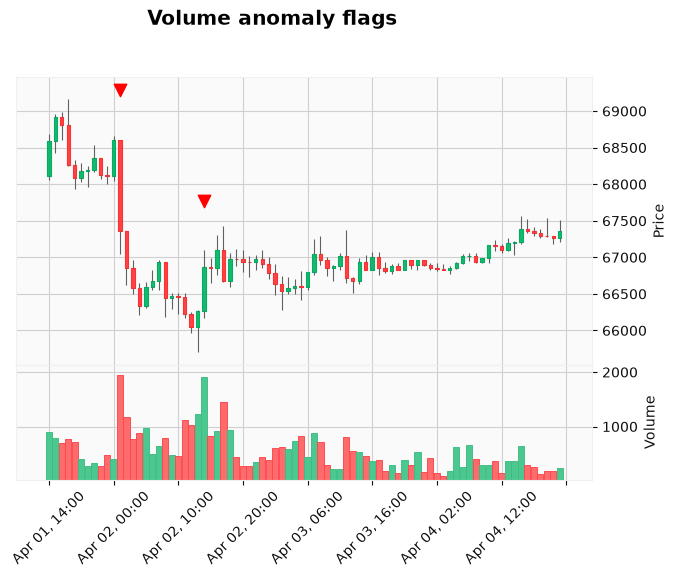

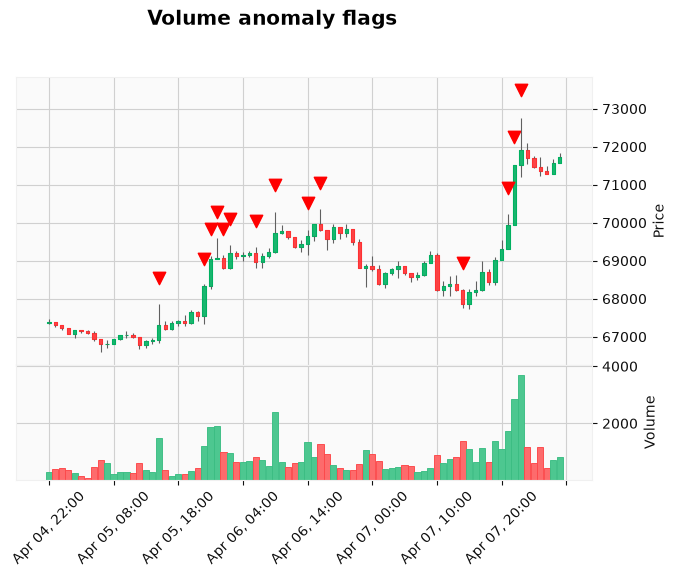

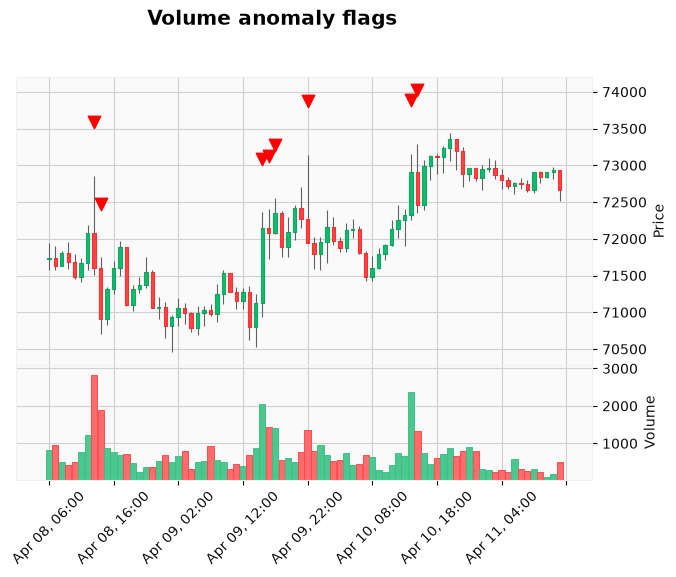

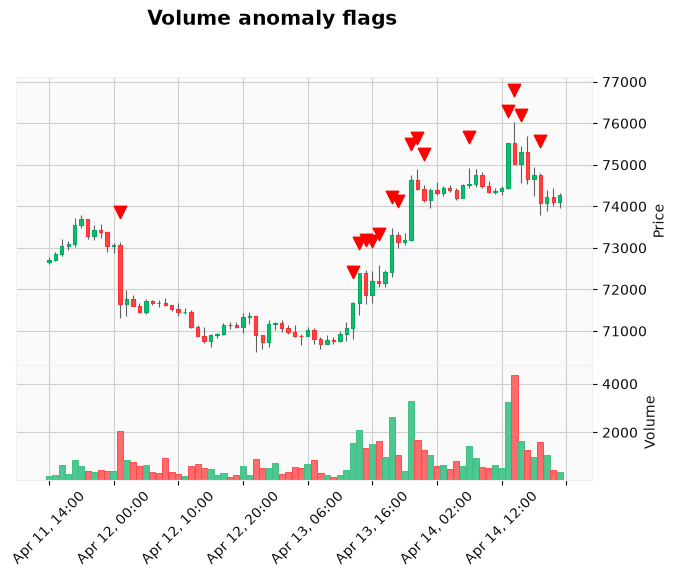

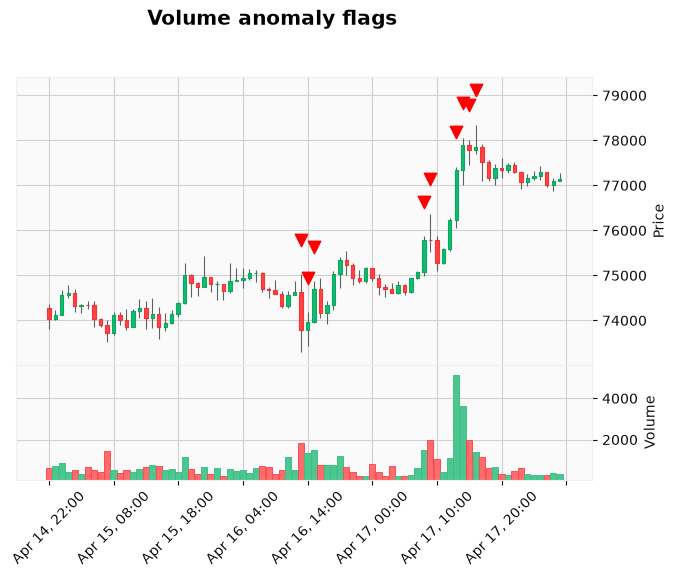

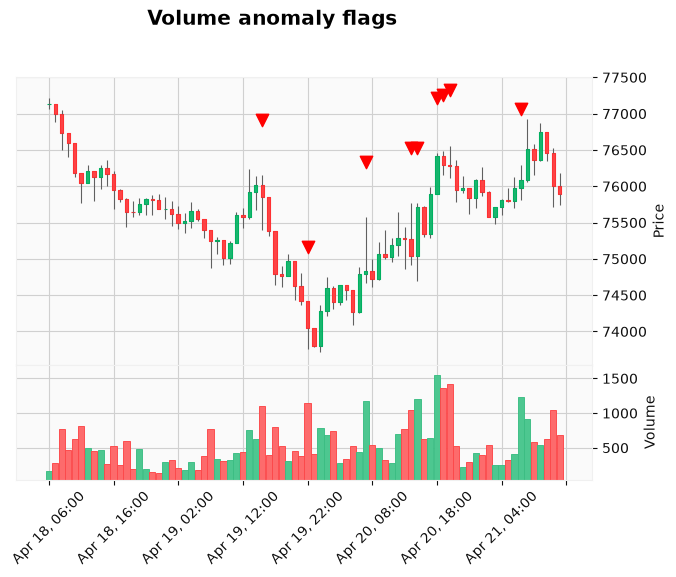

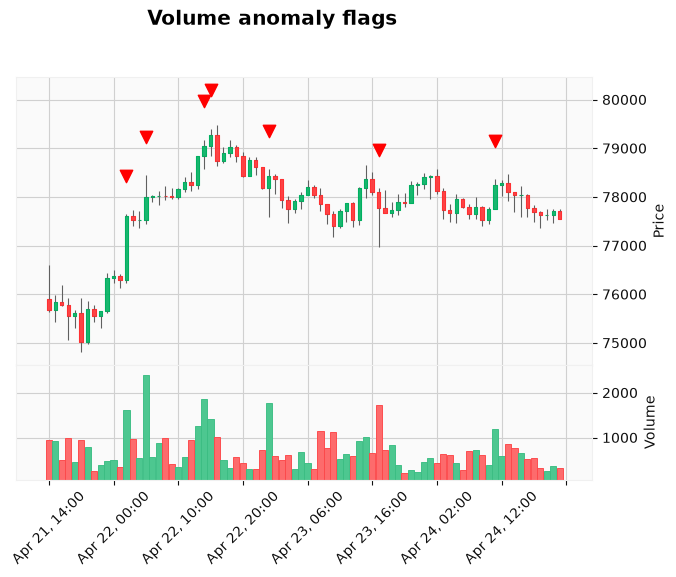

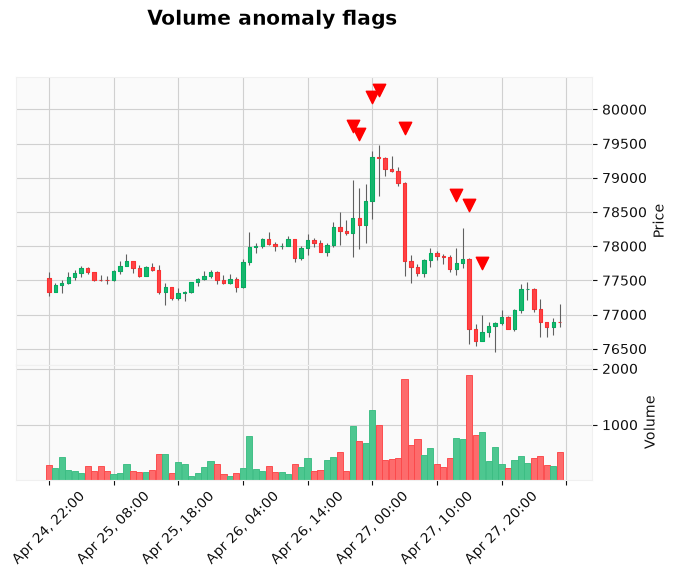

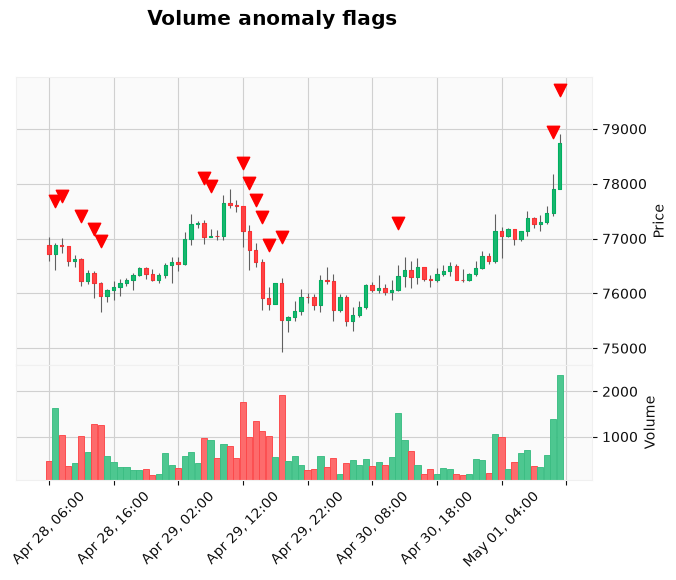

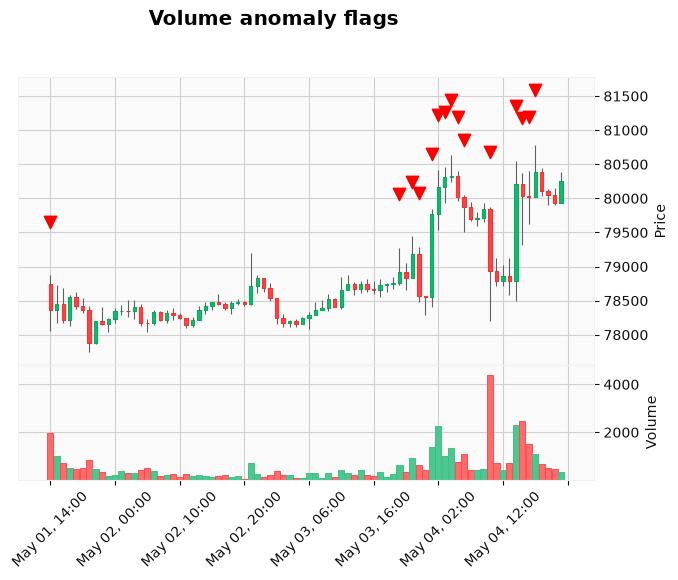

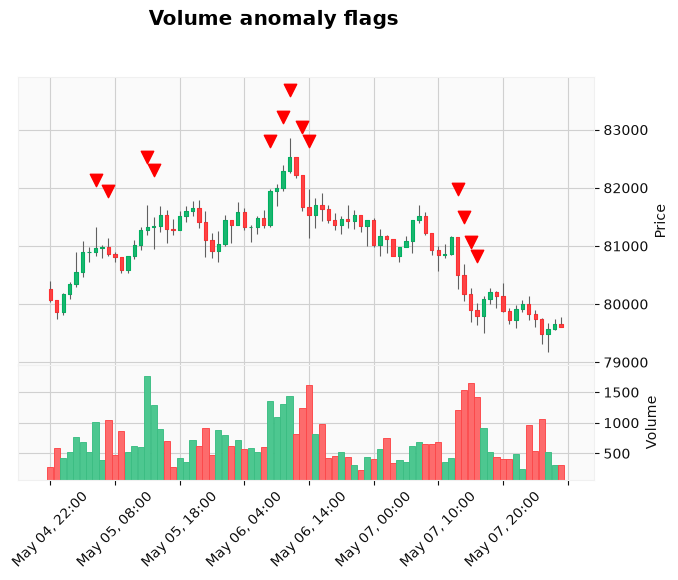

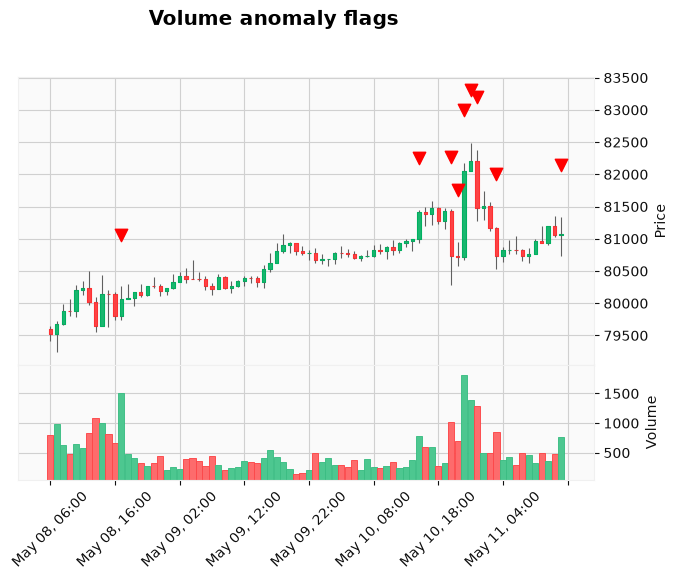

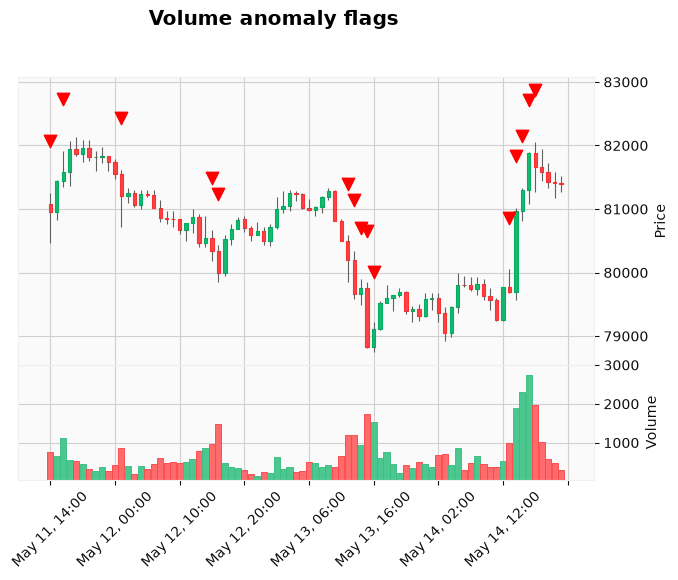

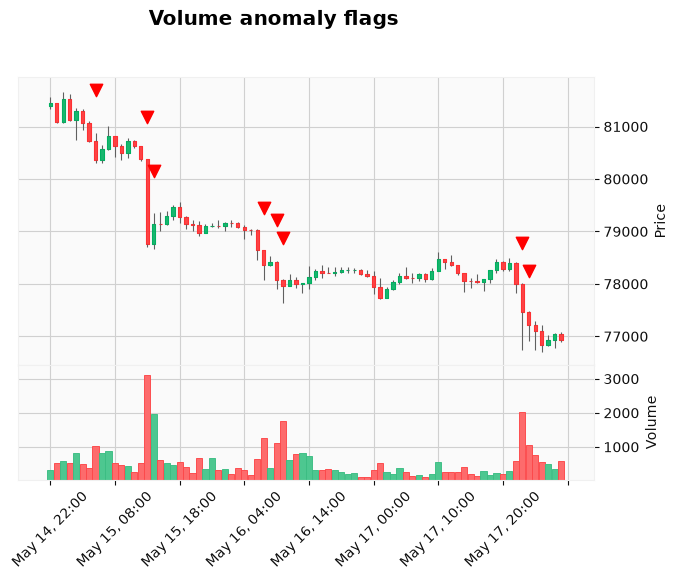

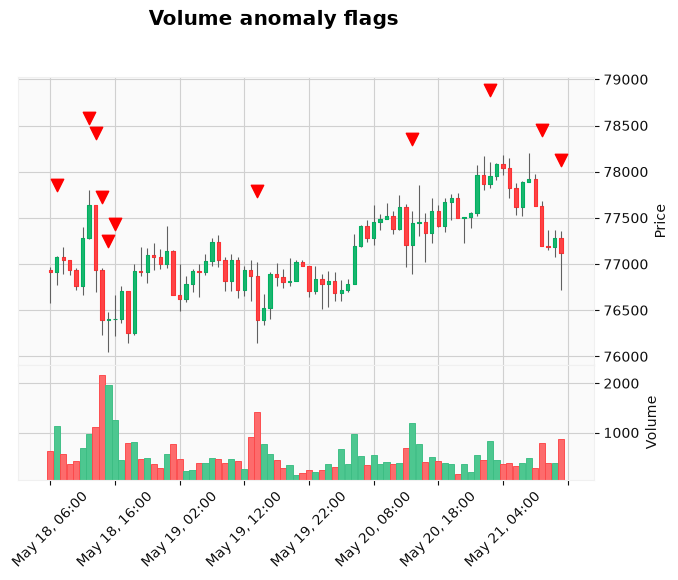

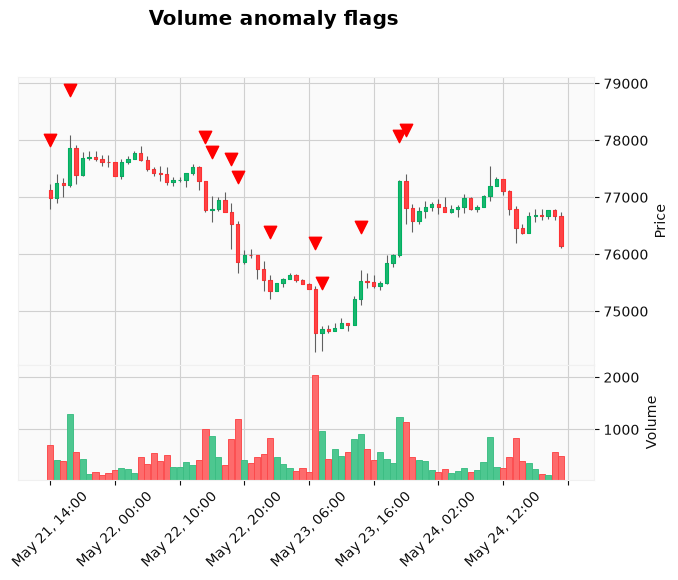

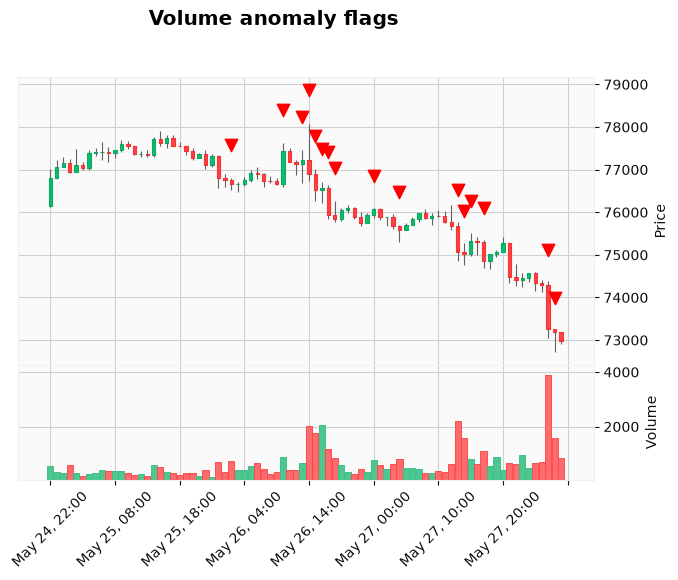

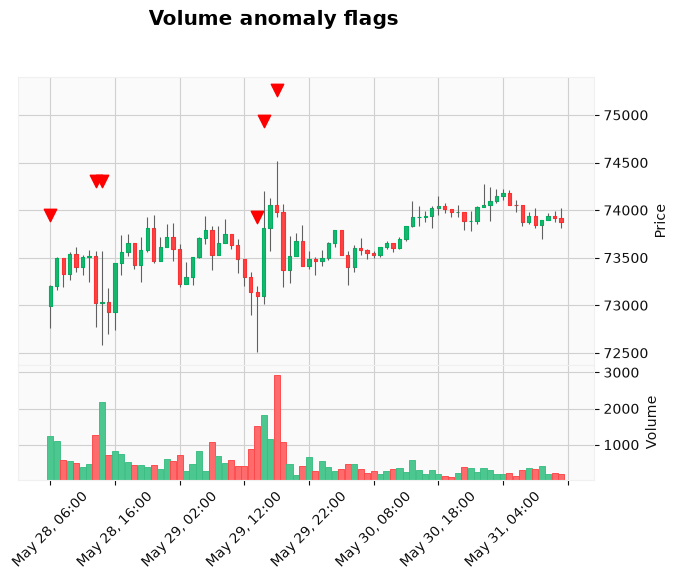

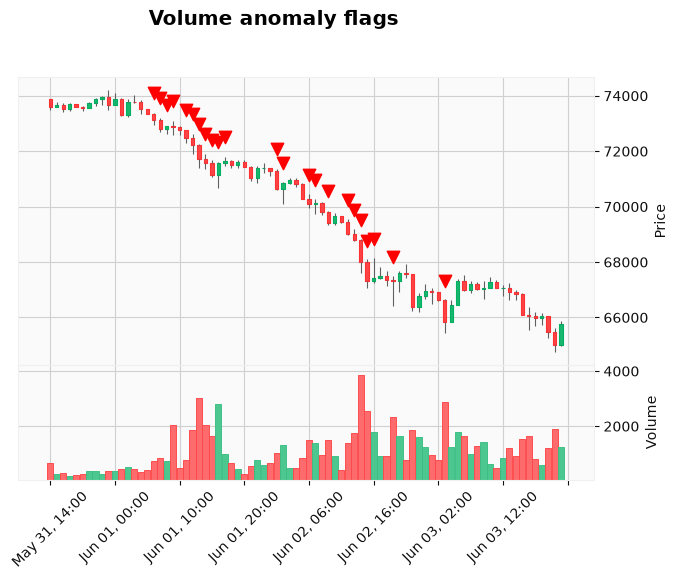

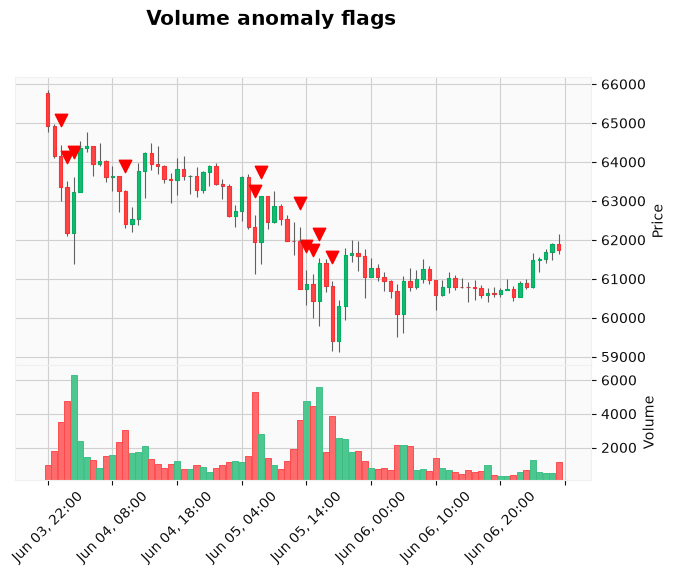

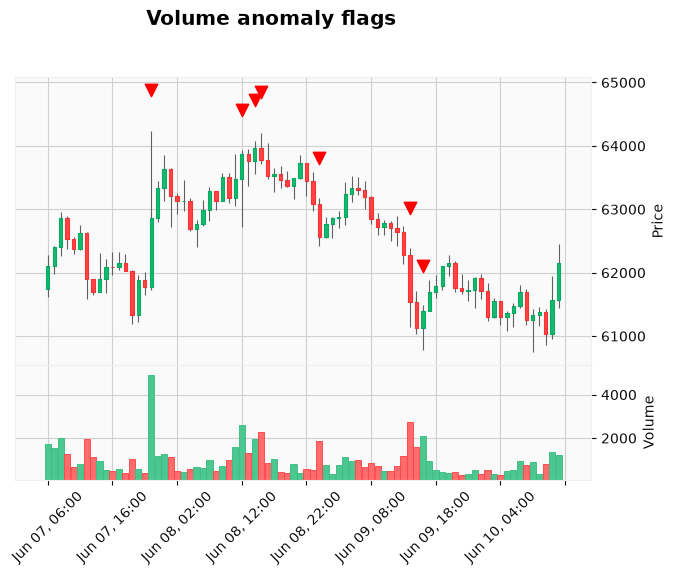

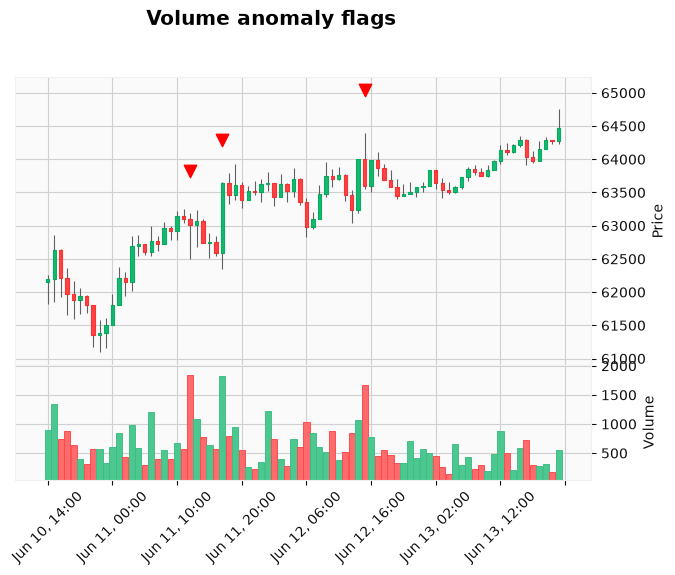

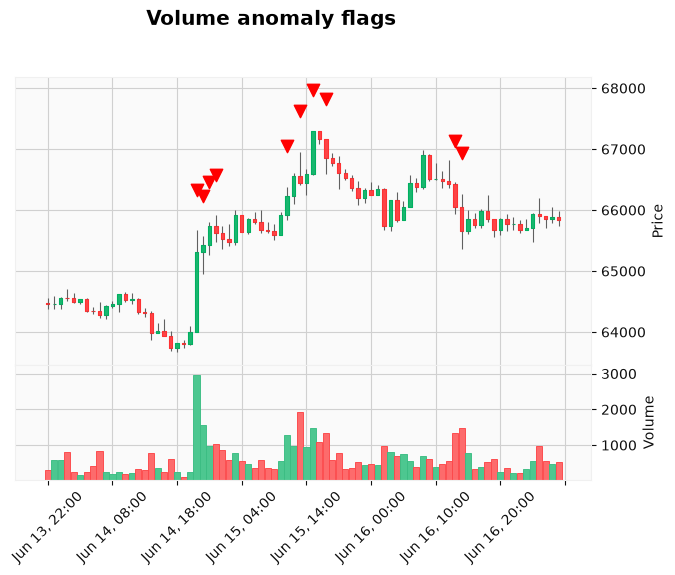

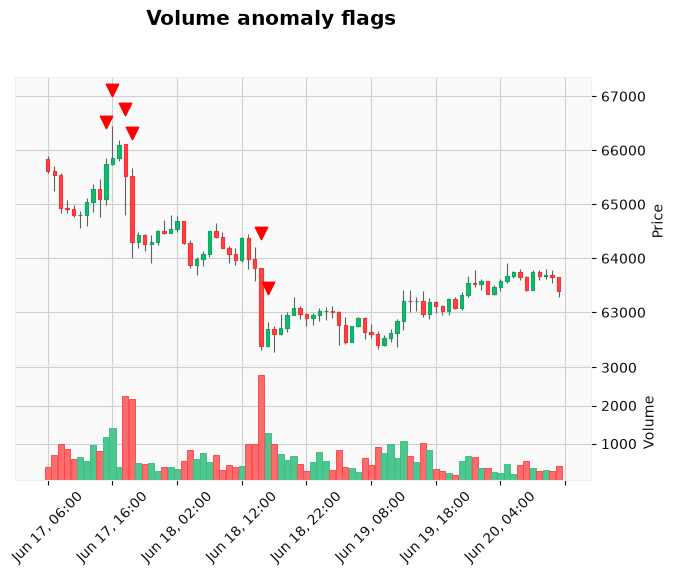

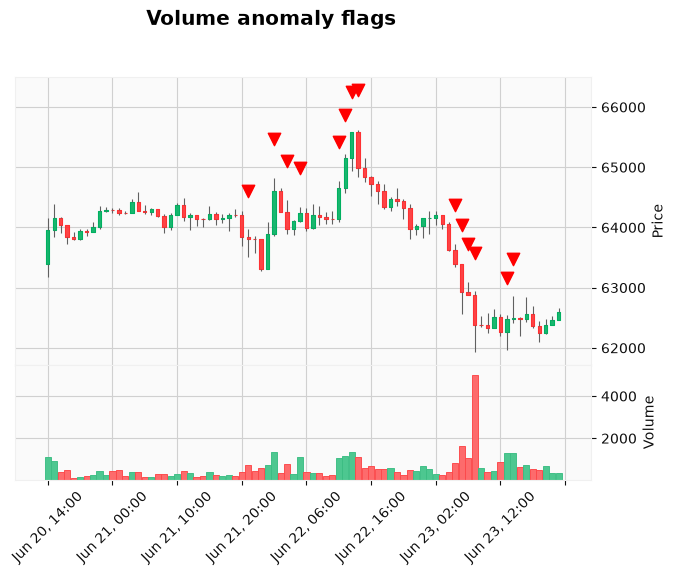

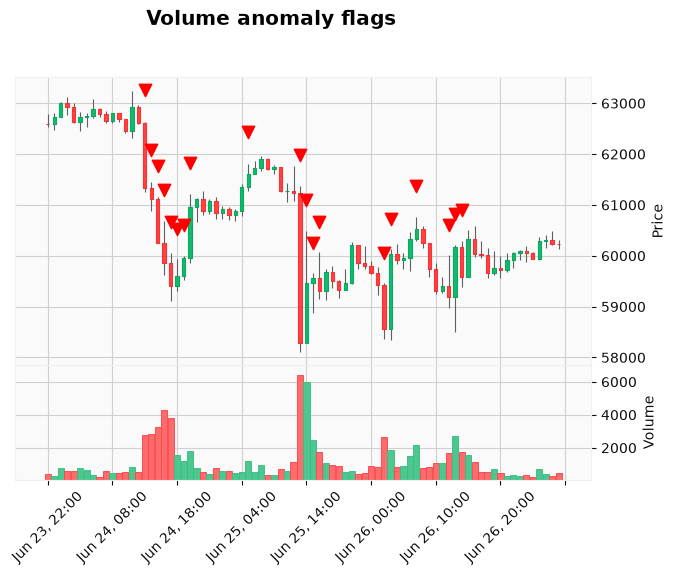

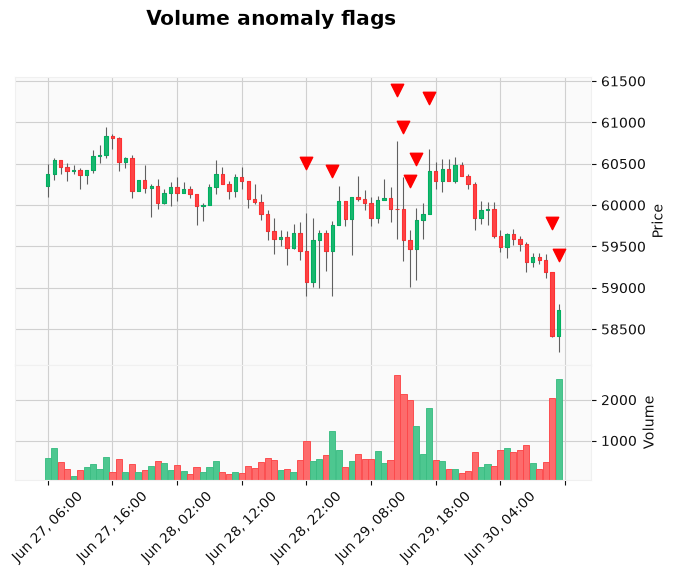

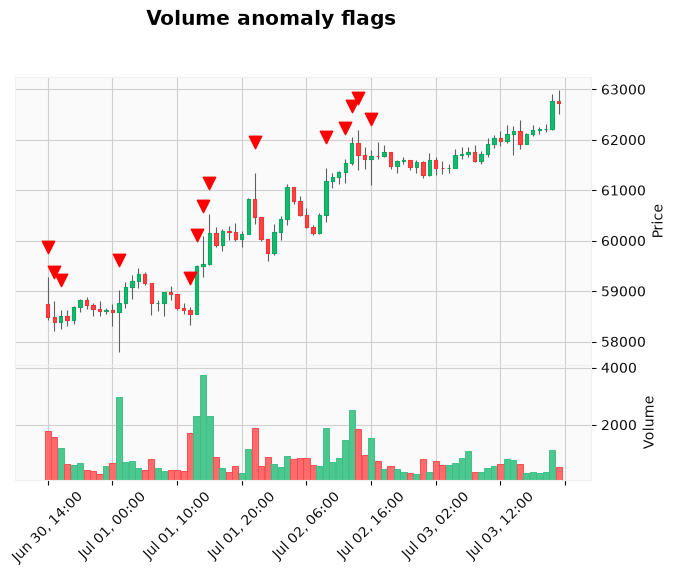

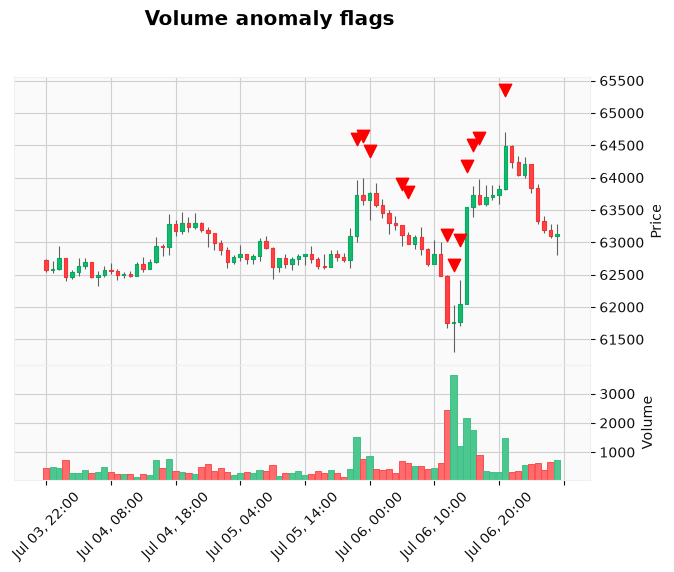

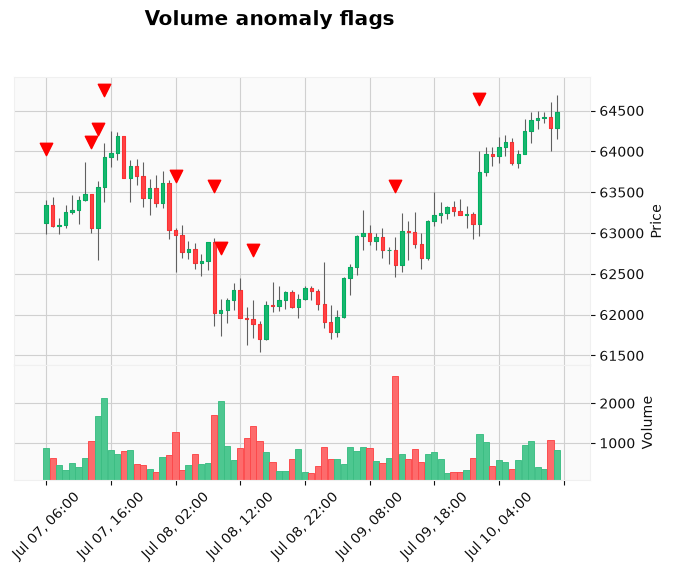

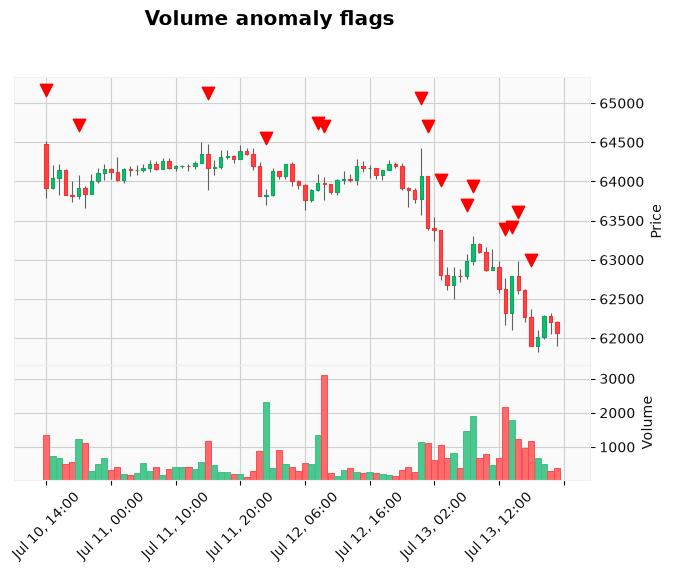

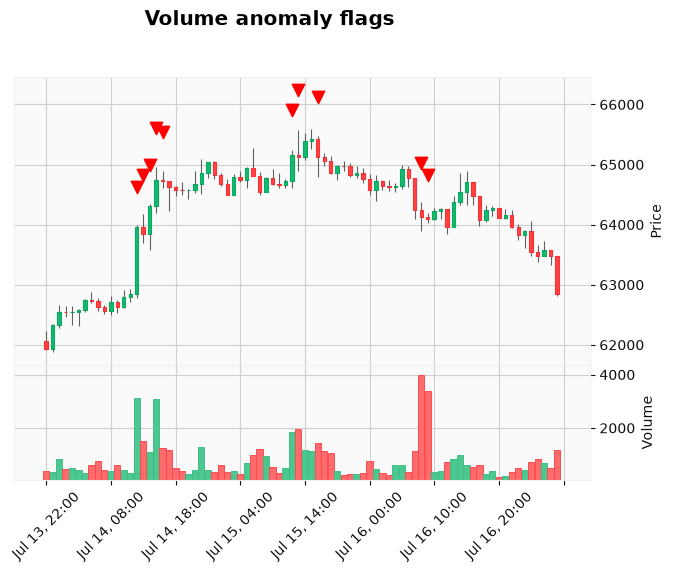

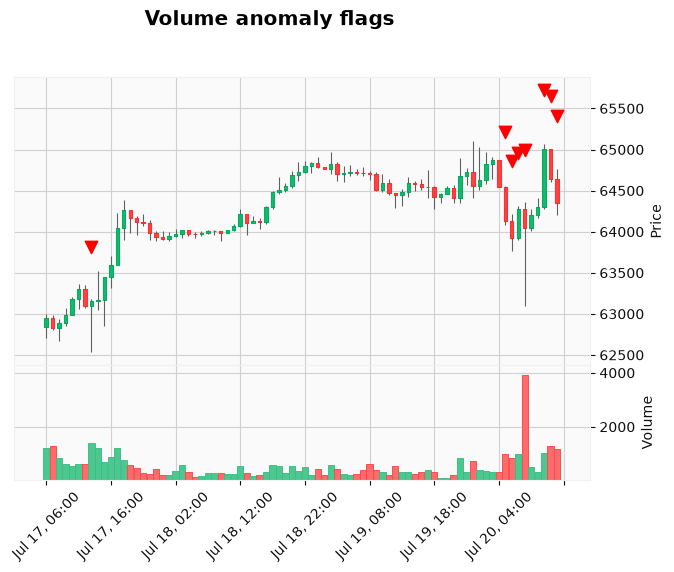

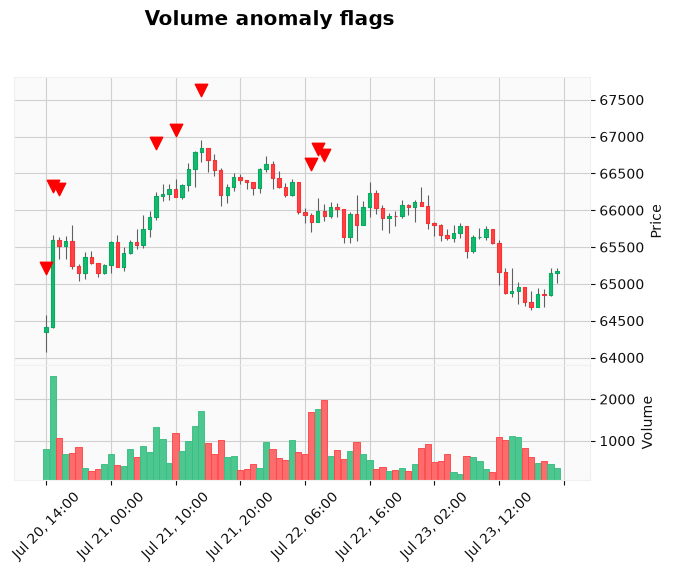

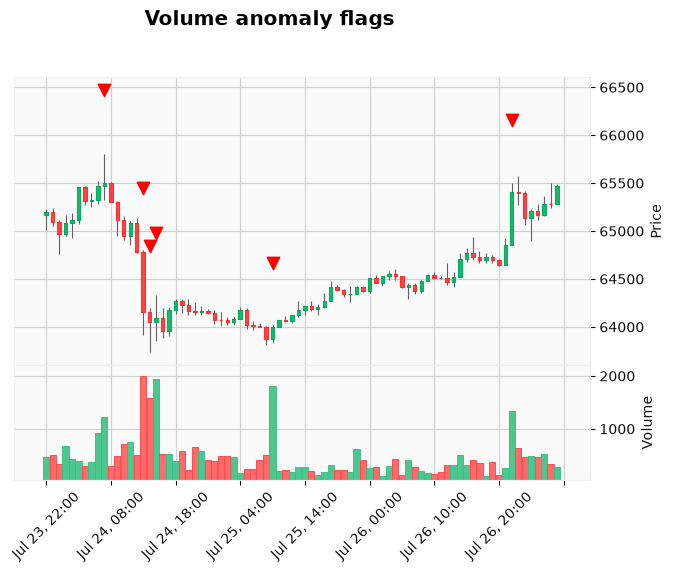

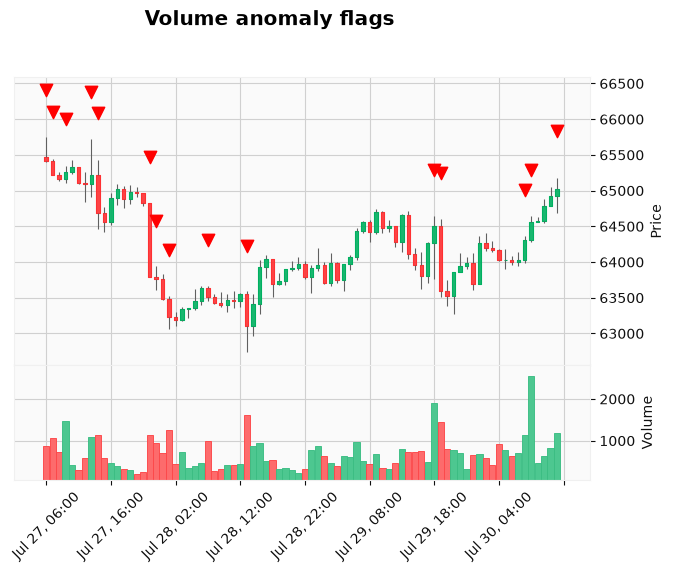

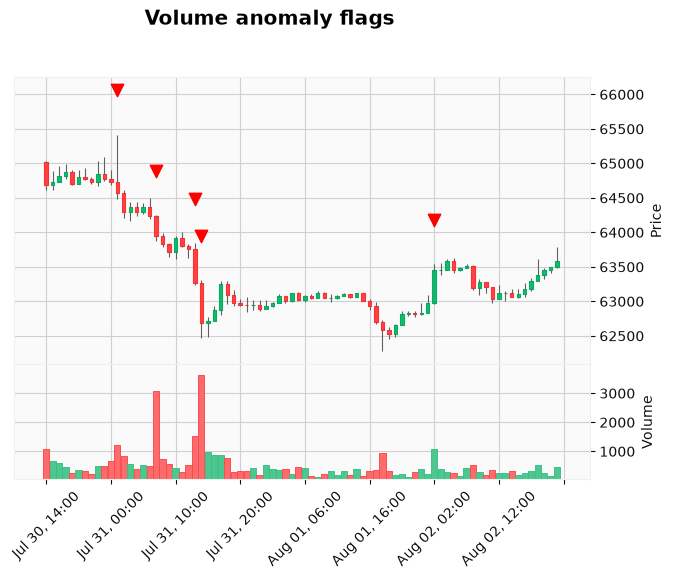

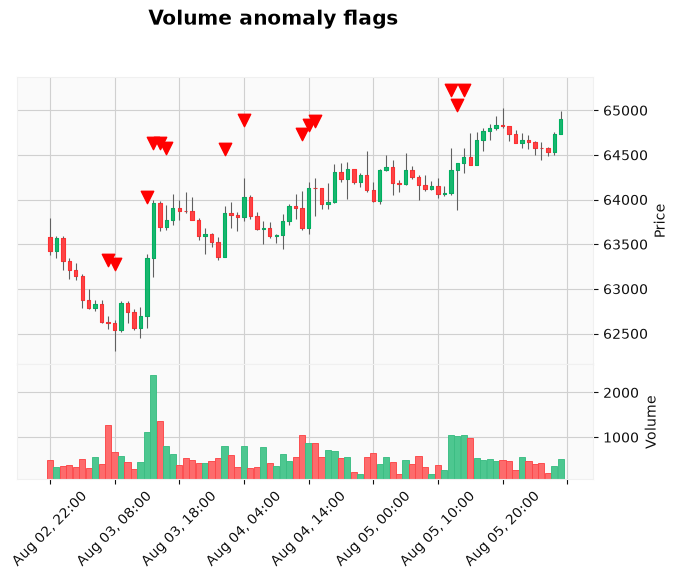

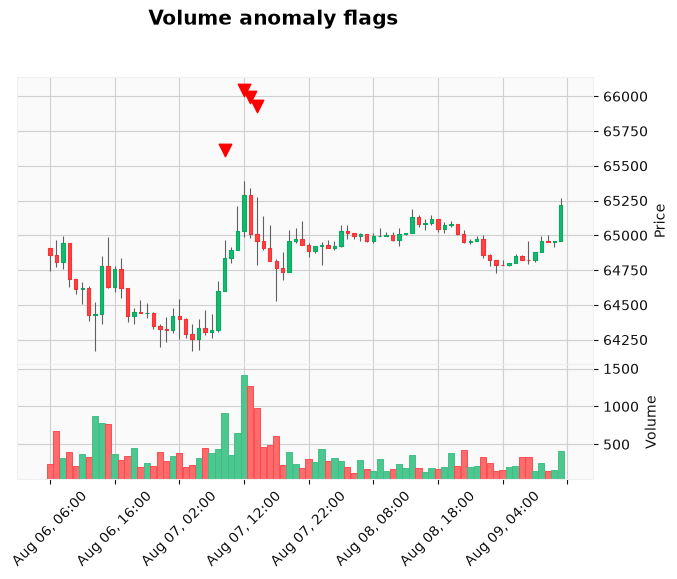

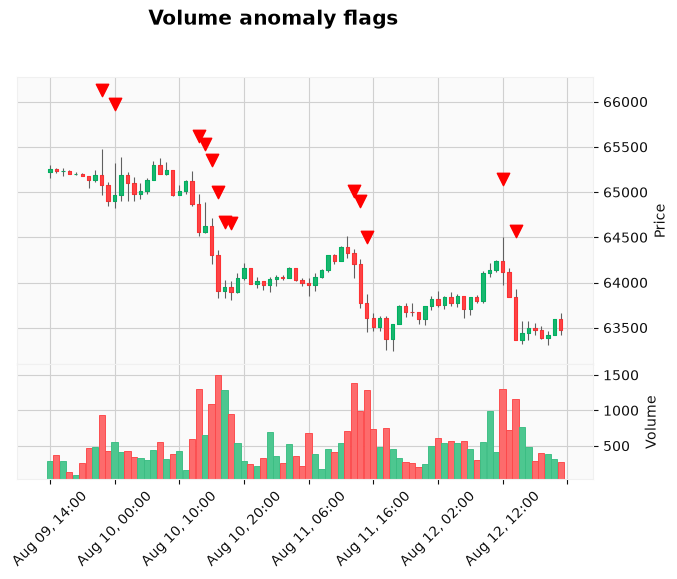

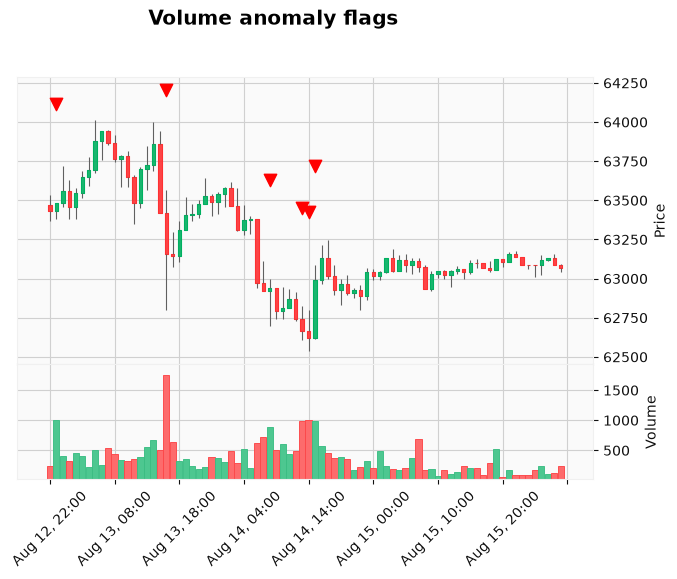

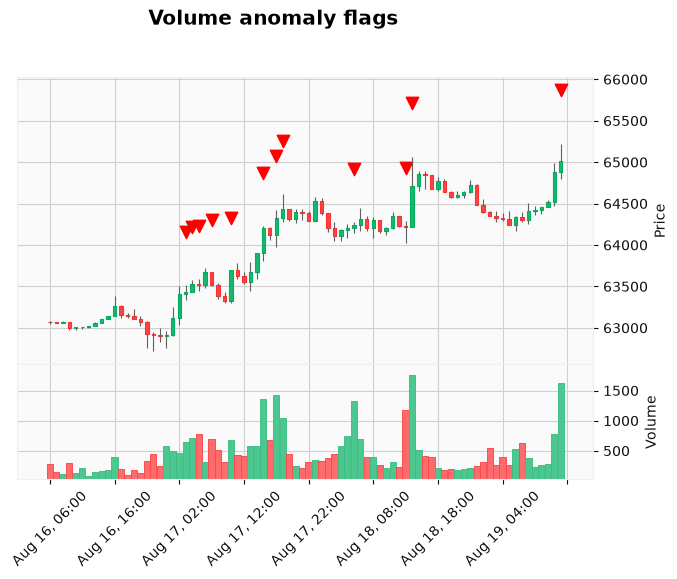

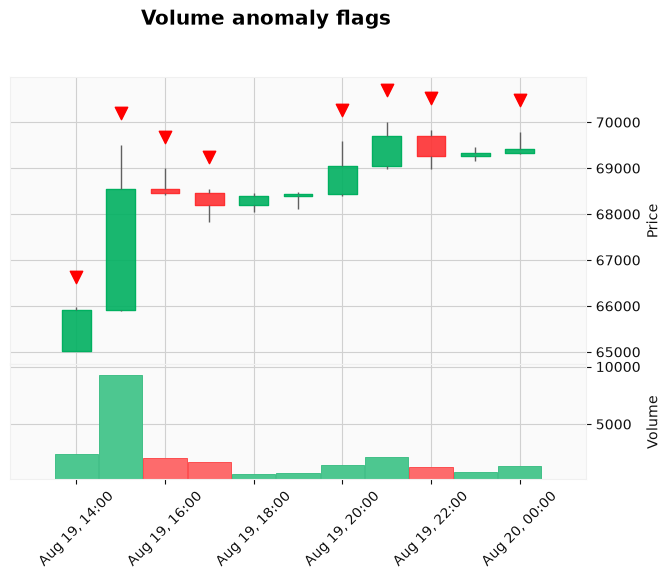

In [106]:
lenght_dataframe = len(temp_data)
for i in range(0, lenght_dataframe, 80) :
    plot_volume_flags(temp_data[i:i + 80], flag_col="volume_flag", title="Volume anomaly flags")


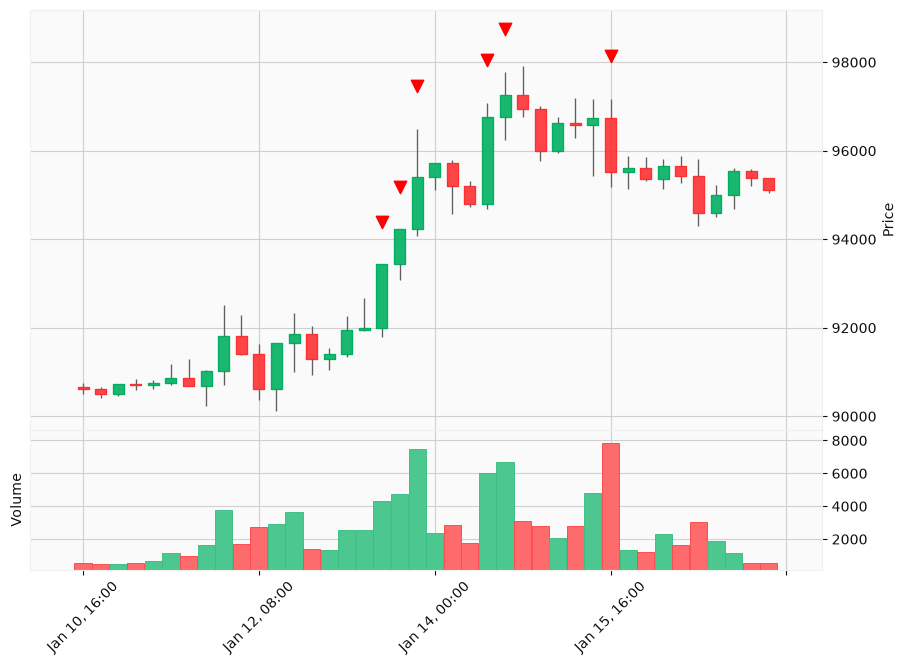

In [65]:
ani = animate_volume_flags(temp_data, flag_col="volume_flag", start=40, step=3, interval=150, n_frames=40)
HTML(ani.to_jshtml())